# Catastrophe theory: numerical companion to the maths sections

This notebook accompanies the mathematical sections of the group report on catastrophe theory. It checks the main formulas numerically and draws the geometry that is hard to picture from algebra alone. All data are simulated, so nothing here is an empirical claim about markets.

**Contents**

1. Fold catastrophe
2. Cusp catastrophe: equilibrium surface, bifurcation set, hysteresis
3. Swallowtail cross-section
4. Elliptic umbilic and its deltoid bifurcation set
5. Stochastic cusp: stationary density, simulation, Cobb-type maximum likelihood, cusp regression with two controls

**Conventions.** Potentials are scaled so the equilibrium conditions are simple polynomials, for example $V = \tfrac14 x^4 + \tfrac12 a x^2 + b x$ for the cusp. These agree with the standard normal forms up to a rescaling of the variables and parameters. Equilibria satisfy $\partial V/\partial x = 0$ and are stable when $\partial^2 V/\partial x^2 > 0$.

**Running it.** `pip install numpy scipy matplotlib jupyter`, then run all cells. Total run time is roughly half a minute.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.integrate import solve_ivp, trapezoid
from scipy.optimize import minimize

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, RED, GREY, GOLD = "#1f5f99", "#c0392b", "#7f8c8d", "#d4a017"
rng = np.random.default_rng(2026)

## 1. Fold

$$V(x;a)=\tfrac13 x^3+ax,\qquad V'(x)=x^2+a,\qquad V''(x)=2x.$$

For $a<0$ there are two equilibria $x=\pm\sqrt{-a}$. The one with $x>0$ is a minimum (stable) and the one with $x<0$ is a maximum (unstable). As $a\to 0^-$ they merge, and for $a>0$ there is no equilibrium. The equilibrium set is the parabola $a=-x^2$, and the catastrophe map (projection onto the $a$-axis) has its only singularity at the fold point $x=0$.

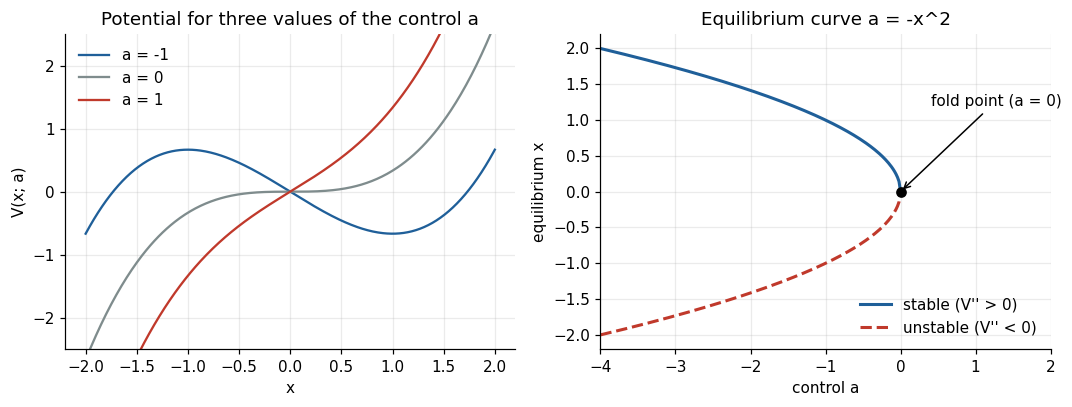

In [2]:
# Fold: V(x; a) = x^3/3 + a x,  V'(x) = x^2 + a,  V''(x) = 2x
x = np.linspace(-2, 2, 400)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))

for a, col in [(-1.0, BLUE), (0.0, GREY), (1.0, RED)]:
    ax[0].plot(x, x**3/3 + a*x, color=col, label=f"a = {a:g}")
ax[0].set_ylim(-2.5, 2.5)
ax[0].set_xlabel("x"); ax[0].set_ylabel("V(x; a)")
ax[0].set_title("Potential for three values of the control a")
ax[0].legend(frameon=False)

a_neg = np.linspace(-4, 0, 200)
ax[1].plot(a_neg, np.sqrt(-a_neg), color=BLUE, lw=2, label="stable (V'' > 0)")
ax[1].plot(a_neg, -np.sqrt(-a_neg), color=RED, lw=2, ls="--", label="unstable (V'' < 0)")
ax[1].scatter([0], [0], color="k", zorder=5)
ax[1].annotate("fold point (a = 0)", (0, 0), (0.4, 1.2), arrowprops=dict(arrowstyle="->"))
ax[1].set_xlim(-4, 2); ax[1].set_xlabel("control a"); ax[1].set_ylabel("equilibrium x")
ax[1].set_title("Equilibrium curve a = -x^2")
ax[1].legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

## 2. Cusp

$$V(x;a,b)=\tfrac14 x^4+\tfrac12 a x^2+b x,\qquad V'=x^3+ax+b,\qquad V''=3x^2+a.$$

The equilibrium set $M=\{V'=0\}$ is a smooth surface, because $b=-x^3-ax$ is a graph over the $(a,x)$-plane. Projecting $M$ onto the control plane $(a,b)$ folds the surface over itself. The fold curves are where $V'=V''=0$: the second equation gives $x^2=-a/3$, and substituting into the first gives
$$4a^3+27b^2=0,$$
which is the discriminant of the cubic $x^3+ax+b$. Inside this cusp-shaped region (where $4a^3+27b^2<0$) the potential has two minima and one maximum, and outside it has one minimum.

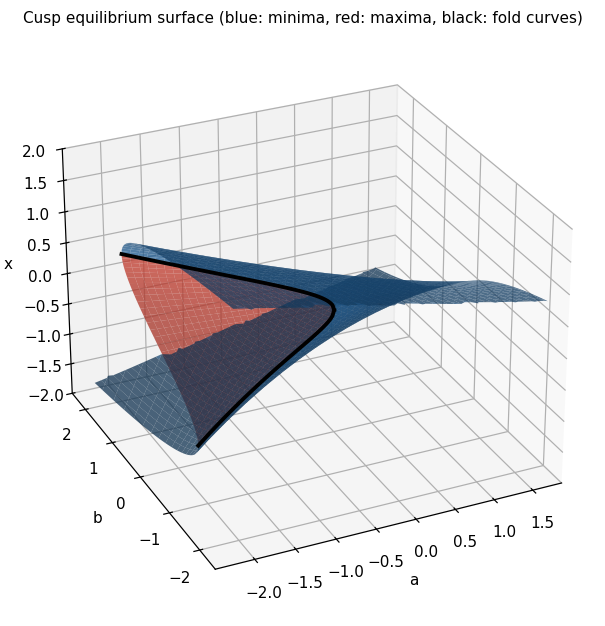

In [3]:
# Cusp: V(x; a, b) = x^4/4 + a x^2/2 + b x,  V' = x^3 + a x + b,  V'' = 3x^2 + a
A, X = np.meshgrid(np.linspace(-2.2, 1.6, 140), np.linspace(-2.0, 2.0, 220))
B = -X**3 - A*X                              # equilibrium surface V' = 0
stable = (3*X**2 + A) > 0                    # minima (V'' > 0) versus maxima (V'' < 0)
B = np.where(np.abs(B) <= 2.5, B, np.nan)    # clip the plotting window in b

fig = plt.figure(figsize=(7.5, 5.8))
ax = fig.add_subplot(111, projection="3d")
for mask, col in [(~stable, RED), (stable, BLUE)]:
    ax.plot_surface(A, np.where(mask, B, np.nan), X, color=col, alpha=0.75,
                    rstride=3, cstride=3, linewidth=0, antialiased=True)
af = np.linspace(-2.2, 0, 100)
for s in (+1, -1):                           # fold curves: V' = V'' = 0
    xf = s*np.sqrt(-af/3)
    ax.plot(af, -xf**3 - af*xf, xf, color="k", lw=2.5, zorder=10)
ax.set_xlabel("a"); ax.set_ylabel("b"); ax.set_zlabel("x")
ax.set_ylim(-2.5, 2.5); ax.set_zlim(-2, 2)
ax.view_init(elev=28, azim=-115)
ax.set_title("Cusp equilibrium surface (blue: minima, red: maxima, black: fold curves)", fontsize=10)
plt.tight_layout(); plt.show()

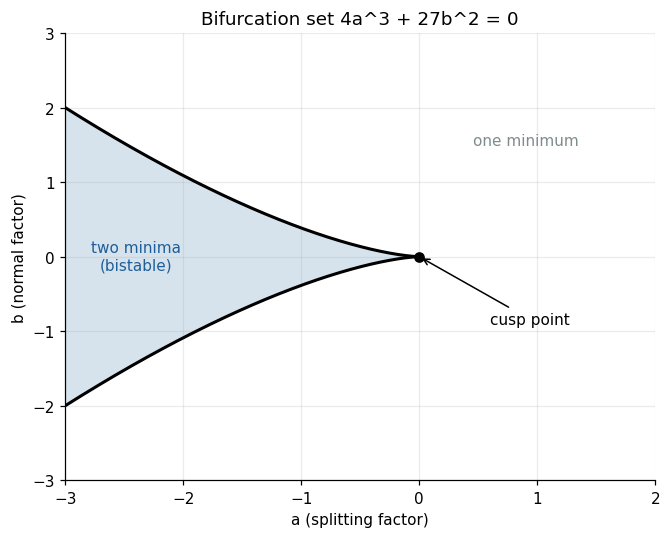

In [4]:
# Control plane (a, b): bifurcation set 4a^3 + 27b^2 = 0 and the region with two minima
aa = np.linspace(-3, 2, 700); bb = np.linspace(-3, 3, 700)
AA, BB = np.meshgrid(aa, bb)
two_minima = 4*AA**3 + 27*BB**2 < 0

fig, ax = plt.subplots(figsize=(6.2, 5))
ax.contourf(AA, BB, two_minima, levels=[0.5, 1.5], colors=[BLUE], alpha=0.18)
a_c = np.linspace(-3, 0, 300)
b_c = np.sqrt(-4*a_c**3/27)
ax.plot(a_c, b_c, color="k", lw=2); ax.plot(a_c, -b_c, color="k", lw=2)
ax.scatter([0], [0], color="k", zorder=5)
ax.text(-2.4, 0, "two minima\n(bistable)", ha="center", va="center", color=BLUE)
ax.text(0.9, 1.5, "one minimum", ha="center", color=GREY)
ax.annotate("cusp point", (0, 0), (0.6, -0.9), arrowprops=dict(arrowstyle="->"))
ax.set_xlabel("a (splitting factor)"); ax.set_ylabel("b (normal factor)")
ax.set_title("Bifurcation set 4a^3 + 27b^2 = 0")
plt.tight_layout(); plt.show()

### Hysteresis

Take $a=-1.5$ and let the system follow the gradient flow $\dot x=-V'(x)$ while $b$ is swept slowly from $-2$ to $2$ and back. The state stays on its current minimum until that minimum disappears at a fold, then jumps to the other branch. This is the delay convention. The jump points in theory are $b=\pm\sqrt{-4a^3/27}$. The simulated jumps occur slightly beyond these values because the sweep rate is finite, and the lag shrinks as the sweep is slowed.

Theory: jumps at b = +/- 0.7071
Simulation: upward sweep jumps at b = 0.7693, downward sweep at b = -0.7693


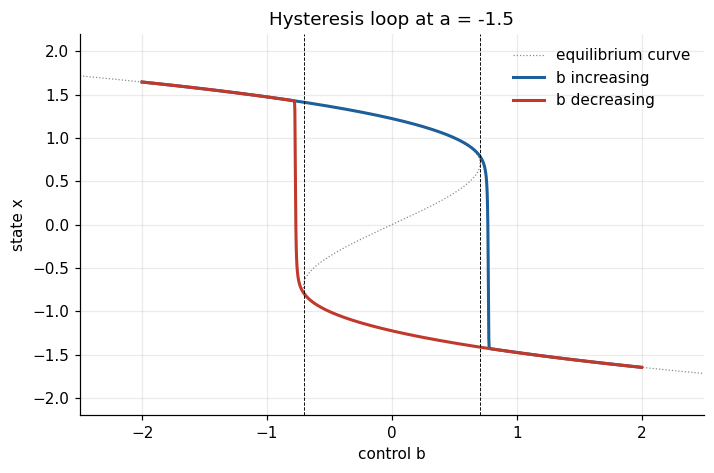

In [5]:
# Hysteresis: slowly sweep b up and then down at a = -1.5 using the gradient flow dx/dt = -V'(x)
a0, B0, T = -1.5, 2.0, 600.0

def rhs_factory(bfun):
    return lambda t, x: -(x**3 + a0*x + bfun(t))

b_up   = lambda t: -B0 + 2*B0*t/T
b_down = lambda t: B0 - 2*B0*(t - T)/T
x_start = np.roots([1, 0, a0, -B0])   # V'(x) = x^3 + a x - B0 = 0 at b = -B0
x_start = x_start[np.abs(x_start.imag) < 1e-9].real.max()

t_up = np.linspace(0, T, 6001)
up = solve_ivp(rhs_factory(b_up), (0, T), [x_start], t_eval=t_up, rtol=1e-8, atol=1e-10)
t_dn = np.linspace(T, 2*T, 6001)
dn = solve_ivp(rhs_factory(b_down), (T, 2*T), [up.y[0, -1]], t_eval=t_dn, rtol=1e-8, atol=1e-10)

b_star = np.sqrt(-4*a0**3/27)
jump_up = b_up(up.t[np.argmax(up.y[0] < 0)])
jump_dn = b_down(dn.t[np.argmax(dn.y[0] > 0)])
print(f"Theory: jumps at b = +/- {b_star:.4f}")
print(f"Simulation: upward sweep jumps at b = {jump_up:.4f}, downward sweep at b = {jump_dn:.4f}")

fig, ax = plt.subplots(figsize=(6.6, 4.4))
xs = np.linspace(-2, 2, 800)
ax.plot(-xs**3 - a0*xs, xs, color=GREY, lw=0.8, ls=":", label="equilibrium curve")
ax.plot(b_up(up.t), up.y[0], color=BLUE, lw=2, label="b increasing")
ax.plot(b_down(dn.t), dn.y[0], color=RED, lw=2, label="b decreasing")
ax.axvline(b_star, color="k", lw=0.6, ls="--"); ax.axvline(-b_star, color="k", lw=0.6, ls="--")
ax.set_xlim(-2.5, 2.5); ax.set_xlabel("control b"); ax.set_ylabel("state x"); ax.set_title("Hysteresis loop at a = -1.5")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 3. Swallowtail cross-section

$$V=\tfrac15x^5+\tfrac13 a x^3+\tfrac12 b x^2+c x,\qquad V'=x^4+ax^2+bx+c.$$

Setting $V'=V''=0$ and solving for $(b,c)$ in terms of $x$ gives the fold set for fixed $a$:
$$b=-2ax-4x^3,\qquad c=ax^2+3x^4.$$
For $a<0$ this curve has two cusps (where $db/dx=dc/dx=0$, at $x^2=-a/6$) and one self-intersection at $(b,c)=(0,a^2/4)$. The shading counts the local minima of $V$: none, one, or two, with the two-minima region bounded by the swallowtail.

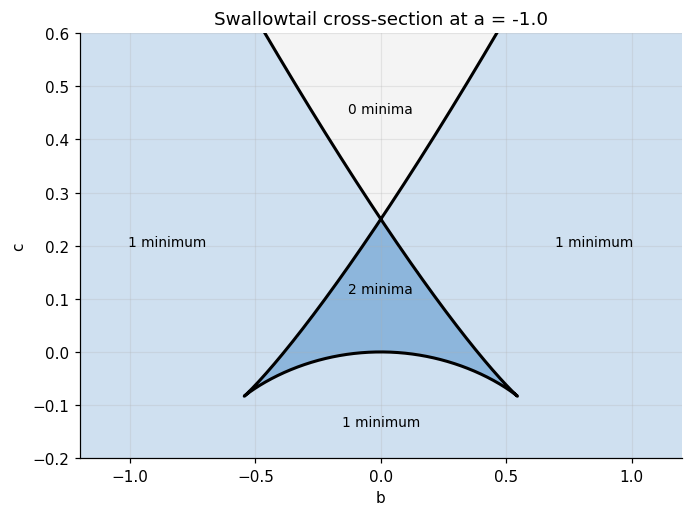

Number of local minima observed: [0, 1, 2]


In [6]:
# Swallowtail: V = x^5/5 + a x^3/3 + b x^2/2 + c x.  Fold set: V' = V'' = 0 gives
#   b = -2 a x - 4 x^3,   c = a x^2 + 3 x^4      (curve in the (b, c) plane for fixed a)
a_fix = -1.0
xg = np.linspace(-1.0, 1.0, 1500)
b_curve = -2*a_fix*xg - 4*xg**3
c_curve = a_fix*xg**2 + 3*xg**4

# number of local minima of V for each (b, c): roots of V' = x^4 + a x^2 + b x + c with + to - ... - to + pattern
def n_local_minima(b, c, a=a_fix):
    r = np.roots([1, 0, a, b, c])
    r = np.sort(r[np.abs(r.imag) < 1e-9].real)
    return len(r)//2                  # V' is + outside its real roots, so minima are every second root

bs = np.linspace(-1.2, 1.2, 240); cs = np.linspace(-0.2, 0.6, 200)
counts = np.array([[n_local_minima(b, c) for b in bs] for c in cs])

fig, ax = plt.subplots(figsize=(6.4, 4.8))
cmap = ListedColormap(["#f4f4f4", "#cfe0f0", "#8db6dc"])
ax.pcolormesh(bs, cs, counts, cmap=cmap, vmin=-0.5, vmax=2.5, shading="auto")
ax.plot(b_curve, c_curve, color="k", lw=2)
ax.set_xlabel("b"); ax.set_ylabel("c"); ax.set_title(f"Swallowtail cross-section at a = {a_fix}")
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-0.2, 0.6)
for (bx, cy, t) in [(0, 0.45, "0 minima"), (0, 0.11, "2 minima"), (-0.85, 0.2, "1 minimum"), (0.85, 0.2, "1 minimum"), (0, -0.14, "1 minimum")]:
    ax.text(bx, cy, t, ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print("Number of local minima observed:", sorted(set(counts.ravel().tolist())))

## 4. Elliptic umbilic

$$V=x^3-3xy^2+a(x^2+y^2)+bx+cy.$$

The Hessian determinant is $4a^2-36(x^2+y^2)$, so degenerate critical points lie on the circle $x^2+y^2=a^2/9$. Writing $(x,y)=\tfrac a3(\cos\theta,\sin\theta)$ and solving $V_x=V_y=0$ for $(b,c)$ gives
$$b=-\tfrac{a^2}{3}\bigl(2\cos\theta+\cos2\theta\bigr),\qquad c=\tfrac{2a^2}{3}(\cos\theta-1)\sin\theta,$$
a hypocycloid with three cusps (a deltoid). Inside it the potential has four critical points and outside it has two.

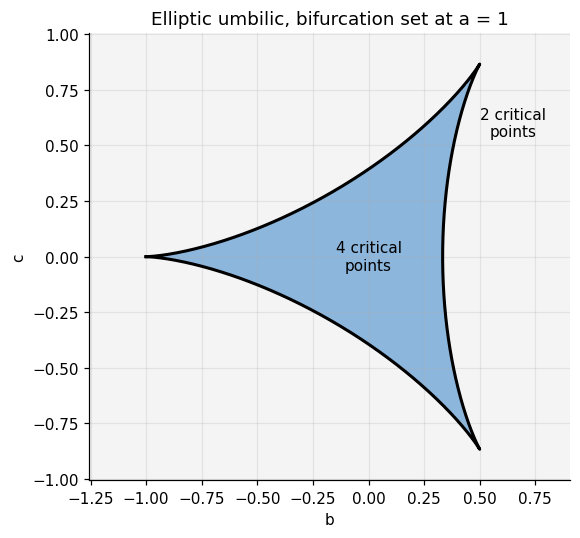

Real critical points observed on the grid: [2, 4]


In [7]:
# Elliptic umbilic: V = x^3 - 3 x y^2 + a (x^2 + y^2) + b x + c y.
# Degenerate critical points lie on x^2 + y^2 = a^2/9; mapping them to (b, c) gives a deltoid (3-cusped hypocycloid).
a_fix = 1.0
th = np.linspace(0, 2*np.pi, 800)
b_d = -a_fix**2*(2*np.cos(th) + np.cos(2*th))/3
c_d = 2*a_fix**2*(np.cos(th) - 1)*np.sin(th)/3

def n_crit(b, c, a=a_fix):
    # eliminate y using V_y = 0: y = -c/(2a - 6x); substitute into V_x = 0 -> quartic in x
    p = np.polynomial.polynomial
    lhs = p.polymul([b, 2*a, 3], p.polypow([2*a, -6], 2))     # (3x^2 + 2a x + b)(2a - 6x)^2
    poly = p.polysub(lhs, [3*c**2])
    r = p.polyroots(poly)
    return int(np.sum(np.abs(r.imag) < 1e-7))

bs = np.linspace(-1.25, 0.9, 200); cs = np.linspace(-1.0, 1.0, 200)
counts = np.array([[n_crit(b, c) for b in bs] for c in cs])

fig, ax = plt.subplots(figsize=(5.6, 5.0))
ax.pcolormesh(bs, cs, counts, cmap=ListedColormap(["#f4f4f4", "#cfe0f0", "#8db6dc"]), vmin=1, vmax=5, shading="auto")
ax.plot(b_d, c_d, color="k", lw=2)
ax.set_aspect("equal"); ax.set_xlabel("b"); ax.set_ylabel("c")
ax.set_title("Elliptic umbilic, bifurcation set at a = 1")
ax.text(0, 0, "4 critical\npoints", ha="center", va="center")
ax.text(0.65, 0.6, "2 critical\npoints", ha="center", va="center")
plt.tight_layout(); plt.show()
print("Real critical points observed on the grid:", sorted(set(counts.ravel().tolist())))

## 5. Stochastic cusp

### 5.1 Stationary density

Add noise to the gradient flow:
$$dY_t=-V'(Y_t)\,dt+\sigma\,dW_t,\qquad V(y)=\tfrac14y^4+\tfrac12ay^2+by.$$
The stationary Fokker-Planck equation with zero probability flux is $V'p+\tfrac{\sigma^2}{2}p'=0$, so
$$p(y)=\psi\exp\!\bigl(-2V(y)/\sigma^2\bigr).$$
Since $p'=-(2/\sigma^2)V'p$, the modes of $p$ are exactly the local minima of $V$. The density is therefore bimodal precisely when $4a^3+27b^2<0$, and the noise level does not change this criterion.

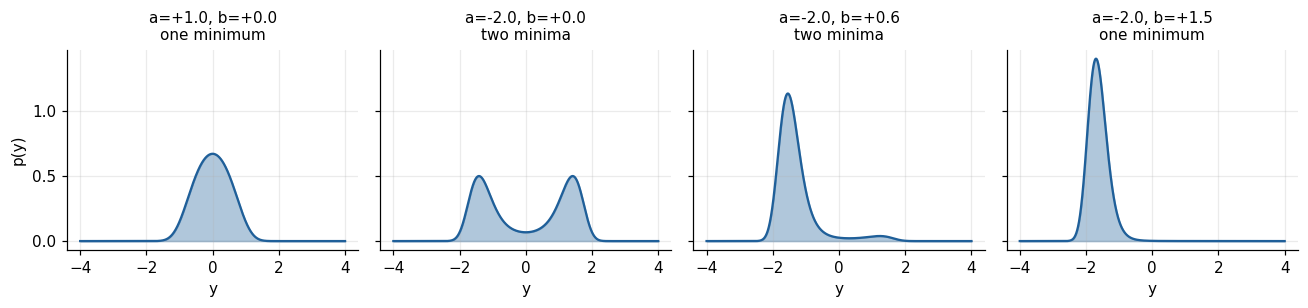

    a     b   4a^3+27b^2  two minima?  modes of p
  1.0   0.0         4.00        False           1
 -2.0   0.0       -32.00         True           2
 -2.0   0.6       -22.28         True           2
 -2.0   1.5        28.75        False           1


In [8]:
# Stochastic cusp: dY = -V'(Y) dt + sigma dW  with  V(y) = y^4/4 + a y^2/2 + b y.
# Stationary density: p(y) = psi * exp(-2 V(y) / sigma^2).  Its modes are exactly the local minima of V.
def V_cusp(y, a, b):
    return y**4/4 + a*y**2/2 + b*y

def stationary_density(y, a, b, sigma=1.0):
    w = np.exp(-2*V_cusp(y, a, b)/sigma**2)
    return w/trapezoid(w, y)

def count_modes(p):
    return int(np.sum((p[1:-1] > p[:-2]) & (p[1:-1] > p[2:])))

y = np.linspace(-4, 4, 4001)
cases = [(1.0, 0.0), (-2.0, 0.0), (-2.0, 0.6), (-2.0, 1.5)]
fig, axes = plt.subplots(1, 4, figsize=(12, 2.9), sharey=True)
rows = []
for ax, (a, b) in zip(axes, cases):
    p = stationary_density(y, a, b)
    ax.fill_between(y, p, color=BLUE, alpha=0.35); ax.plot(y, p, color=BLUE)
    inside = 4*a**3 + 27*b**2 < 0
    ax.set_title(f"a={a:+.1f}, b={b:+.1f}\n" + ("two minima" if inside else "one minimum"), fontsize=10); ax.set_xlabel("y")
    rows.append((a, b, 4*a**3 + 27*b**2, inside, count_modes(p)))
axes[0].set_ylabel("p(y)")
plt.tight_layout(); plt.show()

print(f"{'a':>5} {'b':>5} {'4a^3+27b^2':>12} {'two minima?':>12} {'modes of p':>11}")
for a, b, d, inside, m in rows:
    print(f"{a:5.1f} {b:5.1f} {d:12.2f} {str(inside):>12} {m:11d}")

### 5.2 Simulation

An Euler-Maruyama scheme confirms the stationary density (run with $b=0$ and $\sigma=0.6$, where the state switches between wells) and shows what noise does to the hysteresis loop (a slow sweep with $\sigma=0.3$). With noise, escape from a well can happen before the fold is reached, so the jump points move inside the deterministic values $b=\pm\sqrt{-4a^3/27}$ and the sharp jumps of the deterministic model are blurred.

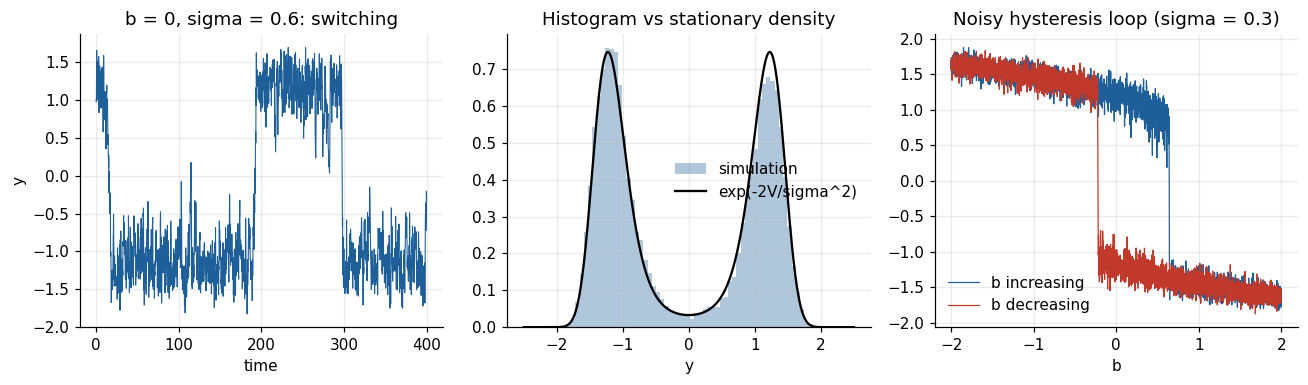

Sign changes of y over the b = 0 run (well-to-well switches): 145


In [9]:
# Euler-Maruyama simulation of the stochastic cusp
def simulate_cusp(a, b_path, sigma, dt, rng, y0=1.0):
    n = len(b_path); y = np.empty(n); y[0] = y0
    noise = rng.standard_normal(n - 1)*np.sqrt(dt)*sigma
    for i in range(n - 1):
        y[i + 1] = y[i] - (y[i]**3 + a*y[i] + b_path[i])*dt + noise[i]
    return y

a, sigma, dt, T = -1.5, 0.6, 0.01, 4000.0
t = np.arange(0, T, dt)

# (i) constant b = 0: noise-induced switching between the two wells, check against the stationary density
y_const = simulate_cusp(a, np.zeros_like(t), sigma, dt, rng)

# (ii) slowly swept b with the same noise: a noisy hysteresis loop
T2, sigma_sweep = 2000.0, 0.3
t2 = np.arange(0, 2*T2, dt)
b_sweep = np.where(t2 < T2, -2 + 4*t2/T2, 2 - 4*(t2 - T2)/T2)
y_sweep = simulate_cusp(a, b_sweep, sigma_sweep, dt, rng, y0=1.6)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
sub = slice(0, int(400/dt), 20)
ax[0].plot(t[sub], y_const[sub], color=BLUE, lw=0.7)
ax[0].set_xlabel("time"); ax[0].set_ylabel("y"); ax[0].set_title("b = 0, sigma = 0.6: switching")

yy = np.linspace(-2.5, 2.5, 800)
ax[1].hist(y_const[::20], bins=60, density=True, color=BLUE, alpha=0.35, label="simulation")
ax[1].plot(yy, stationary_density(yy, a, 0.0, sigma), color="k", label="exp(-2V/sigma^2)")
ax[1].set_xlabel("y"); ax[1].set_title("Histogram vs stationary density"); ax[1].legend(frameon=False)

half = len(t2)//2
s2 = slice(0, half, 50); s3 = slice(half, None, 50)
ax[2].plot(b_sweep[s2], y_sweep[s2], color=BLUE, lw=0.8, label="b increasing")
ax[2].plot(b_sweep[s3], y_sweep[s3], color=RED, lw=0.8, label="b decreasing")
ax[2].set_xlabel("b"); ax[2].set_title("Noisy hysteresis loop (sigma = 0.3)"); ax[2].legend(frameon=False)
plt.tight_layout(); plt.show()

sw = np.sum(np.diff(np.sign(y_const[::20])) != 0)
print(f"Sign changes of y over the b = 0 run (well-to-well switches): {sw}")

### 5.3 Cobb-type maximum likelihood

Following Cobb, use the standardised variable $z=(y-\lambda)/s$ and the density
$$f(z)=\psi\exp\!\bigl(\alpha z+\tfrac12\beta z^2-\tfrac14z^4\bigr).$$
This is the stationary density of $dz=(\alpha+\beta z-z^3)\,dt+\sqrt2\,dW$, so $\alpha=-b$ (asymmetry, the normal factor) and $\beta=-a$ (bifurcation, the splitting factor) in the notation above. The density is bimodal iff $\beta>0$ and $27\alpha^2<4\beta^3$. The normalising constant has no closed form and is computed by numerical quadrature inside the likelihood. The parametrisation here is one common convention, and exact conventions differ between papers and software.

The test below simulates two data sets, one from a bimodal cusp and one from a Gaussian, and compares the fitted cusp density with a fitted Gaussian using AIC and BIC. No single test rejects a catastrophe model, so likelihood-based comparison against alternatives is the standard approach.

In [10]:
# Cobb-type density for standardised z = (y - lam)/s:   f(z) = psi * exp(alpha z + beta z^2/2 - z^4/4)
# alpha = asymmetry (normal factor), beta = bifurcation (splitting factor); bimodal iff beta > 0 and 27 alpha^2 < 4 beta^3.
ZG = np.linspace(-7, 7, 1601)

def log_unnorm(z, alpha, beta):
    return alpha*z + beta*z**2/2 - z**4/4

def log_const(alpha, beta, zg=ZG):
    """log of the normalising integral (vectorised over alpha, beta)."""
    alpha = np.atleast_1d(alpha)[:, None]; beta = np.atleast_1d(beta)[:, None]
    lu = log_unnorm(zg[None, :], alpha, beta)
    m = lu.max(axis=1, keepdims=True)
    return (m + np.log(trapezoid(np.exp(lu - m), zg, axis=1)[:, None]))[:, 0]

def sample_z(alpha, beta, rng, zg=ZG):
    """Inverse-CDF sampling; alpha, beta may be arrays (one draw per element)."""
    alpha = np.atleast_1d(alpha); beta = np.atleast_1d(beta)
    out = np.empty(len(alpha))
    for i in range(len(alpha)):
        lu = log_unnorm(zg, alpha[i], beta[i]); p = np.exp(lu - lu.max())
        cdf = np.cumsum(p); cdf /= cdf[-1]
        out[i] = np.interp(rng.random(), cdf, zg)
    return out

def nll_cusp(theta, y):
    alpha, beta, lam, logs = theta; s = np.exp(logs)
    z = (y - lam)/s
    return -np.sum(log_unnorm(z, alpha, beta) - log_const(alpha, beta)[0]) + len(y)*logs

def fit_cusp(y, starts=((0.0, -1.0), (0.0, 1.0), (0.0, 3.0))):
    best = None
    for a0, b0 in starts:
        x0 = [a0, b0, np.mean(y), np.log(np.std(y))]
        r = minimize(nll_cusp, x0, args=(y,), method="L-BFGS-B",
                     bounds=[(-8, 8), (-8, 14), (None, None), (-4, 4)])
        if best is None or r.fun < best.fun:
            best = r
    return best

def fit_gauss(y):
    mu, sd = np.mean(y), np.std(y)
    return mu, sd, np.sum(-0.5*np.log(2*np.pi*sd**2) - 0.5*((y - mu)/sd)**2)

def ic(loglik, k, n):
    return 2*k - 2*loglik, k*np.log(n) - 2*loglik   # AIC, BIC

A (cusp truth)    : cusp loglik   -2343.8  AIC    4695.7  BIC    4716.9 | Gaussian loglik   -2714.0  AIC    5432.0  BIC    5442.6


B (Gaussian truth): cusp loglik   -2400.2  AIC    4808.4  BIC    4829.6 | Gaussian loglik   -2401.0  AIC    4806.0  BIC    4816.7

Fit to A: alpha=0.317 (true 0.3), beta=1.995 (true 2.0), lambda=0.484 (true 0.5), s=1.215 (true 1.2)
Bimodal region at the fit (beta>0 and 27 alpha^2 < 4 beta^3): True


Bootstrap SE (alpha, beta, lambda, s): [0.027 0.075 0.023 0.018]


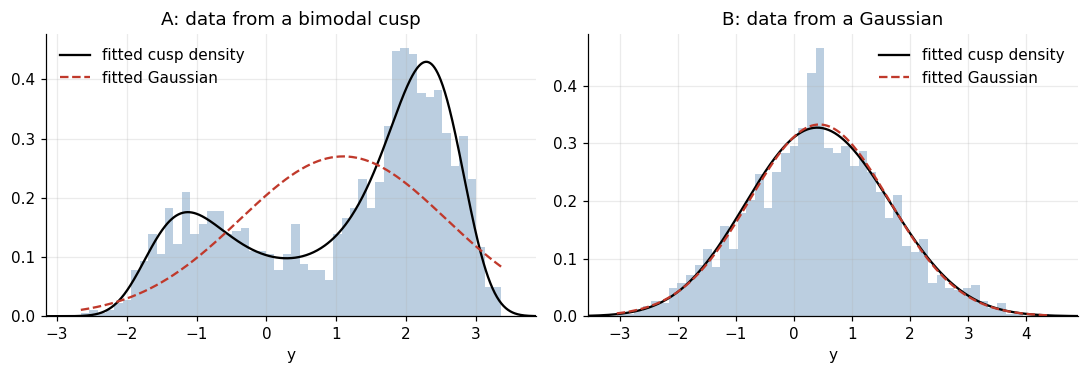

In [11]:
# Two simulated data sets: (A) generated by a bimodal cusp, (B) generated by a Gaussian
n = 1500
true = dict(alpha=0.3, beta=2.0, lam=0.5, s=1.2)
yA = true["lam"] + true["s"]*sample_z(np.full(n, true["alpha"]), np.full(n, true["beta"]), rng)
yB = rng.normal(0.5, 1.2, n)

def report(name, y):
    r = fit_cusp(y); ll_c = -r.fun
    mu, sd, ll_g = fit_gauss(y)
    aic_c, bic_c = ic(ll_c, 4, len(y)); aic_g, bic_g = ic(ll_g, 2, len(y))
    print(f"{name}: cusp loglik {ll_c:9.1f}  AIC {aic_c:9.1f}  BIC {bic_c:9.1f} | "
          f"Gaussian loglik {ll_g:9.1f}  AIC {aic_g:9.1f}  BIC {bic_g:9.1f}")
    return r

rA = report("A (cusp truth)    ", yA)
rB = report("B (Gaussian truth)", yB)
al, be, lam, ls = rA.x
print(f"\nFit to A: alpha={al:.3f} (true {true['alpha']}), beta={be:.3f} (true {true['beta']}), "
      f"lambda={lam:.3f} (true {true['lam']}), s={np.exp(ls):.3f} (true {true['s']})")
print("Bimodal region at the fit (beta>0 and 27 alpha^2 < 4 beta^3):", be > 0 and 27*al**2 < 4*be**3)

# Parametric bootstrap standard errors for data set A
B = 100; boots = []
for _ in range(B):
    yb = lam + np.exp(ls)*sample_z(np.full(n, al), np.full(n, be), rng)
    rb = fit_cusp(yb, starts=((al, be),))
    boots.append([rb.x[0], rb.x[1], rb.x[2], np.exp(rb.x[3])])
se = np.std(boots, axis=0)
print("Bootstrap SE (alpha, beta, lambda, s):", np.round(se, 3))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
for a_, y_, r_, ttl in [(ax[0], yA, rA, "A: data from a bimodal cusp"), (ax[1], yB, rB, "B: data from a Gaussian")]:
    a_.hist(y_, bins=50, density=True, color=BLUE, alpha=0.3)
    zz = ZG; al_, be_, la_, ls_ = r_.x; s_ = np.exp(ls_)
    dens = np.exp(log_unnorm(zz, al_, be_) - log_const(al_, be_)[0])/s_
    a_.plot(la_ + s_*zz, dens, color="k", label="fitted cusp density")
    mu_, sd_, _ = fit_gauss(y_)
    xx = np.linspace(y_.min(), y_.max(), 500)
    a_.plot(xx, np.exp(-0.5*((xx - mu_)/sd_)**2)/(sd_*np.sqrt(2*np.pi)), color=RED, ls="--", label="fitted Gaussian")
    a_.set_xlim(y_.min() - 0.5, y_.max() + 0.5); a_.set_title(ttl); a_.set_xlabel("y"); a_.legend(frameon=False)
plt.tight_layout(); plt.show()

### 5.4 Cusp regression with two controls

Zeeman's stock market model assigns the two controls of the cusp to two groups of traders: a normal (asymmetry) factor driven by fundamentalists and a splitting (bifurcation) factor driven by chartists. Empirical work lets the two cusp parameters depend linearly on observed indicators,
$$\alpha_t=a_0+a_1c_{1,t},\qquad \beta_t=b_0+b_1c_{2,t},$$
and estimates $(a_0,a_1,b_0,b_1,\lambda,s)$ by maximum likelihood, then compares the fit with a linear regression. Here $c_1,c_2$ are simulated AR(1) series and $y_t$ is drawn from the conditional cusp density. The exercise checks that the estimator recovers known coefficients and that the cusp model beats OLS when the data really are bistable. Treating each $y_t$ as a draw from its conditional stationary density ignores serial dependence, which is a simplification.

 param     true  estimate
    a0     0.00     0.002
    a1     0.80     0.887
    b0     1.00     1.039
    b1     1.20     1.170
   lam     0.00    -0.013
     s     1.00     1.006

Cusp regression: loglik  -1157.6, AIC   2327.3, BIC   2356.7
OLS benchmark:   loglik  -1391.0, AIC   2789.9, BIC   2809.6

Share of periods in the bimodal region: true 0.39, fitted 0.38


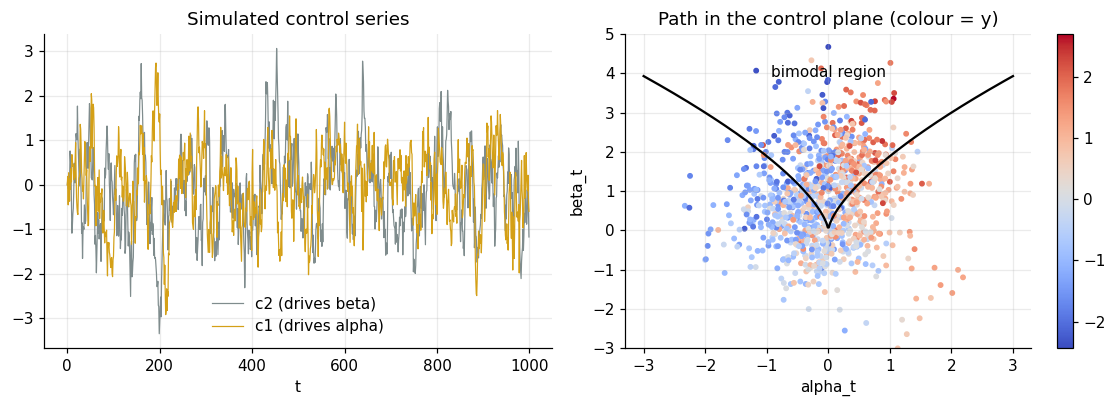

In [12]:
# Cusp regression in the style of Zeeman's stock market model:
#   asymmetry  alpha_t = a0 + a1 * c1_t   (fundamentalist control)
#   bifurcation beta_t = b0 + b1 * c2_t   (chartist / speculative control)
ZR = np.linspace(-6.5, 6.5, 501)

def nll_reg(theta, y, c1, c2):
    a0, a1, b0, b1, lam, logs = theta; s = np.exp(logs)
    alpha = a0 + a1*c1; beta = b0 + b1*c2
    z = (y - lam)/s
    return -np.sum(log_unnorm(z, alpha, beta) - log_const(alpha, beta, ZR)) + len(y)*logs

def fit_reg(y, c1, c2):
    best = None
    for b0_start in (0.5, 2.0):
        x0 = [0.0, 0.1, b0_start, 0.1, np.mean(y), np.log(np.std(y))]
        r = minimize(nll_reg, x0, args=(y, c1, c2), method="L-BFGS-B",
                     bounds=[(-4, 4), (-4, 4), (-4, 4), (-4, 4), (-2, 2), (-1.5, 1.5)])
        if best is None or r.fun < best.fun:
            best = r
    return best

def ar1(n, phi, rng):
    e = rng.standard_normal(n); x = np.zeros(n)
    for i in range(1, n):
        x[i] = phi*x[i-1] + np.sqrt(1 - phi**2)*e[i]
    return x

n = 1000
c1, c2 = ar1(n, 0.9, rng), ar1(n, 0.9, rng)
true_reg = dict(a0=0.0, a1=0.8, b0=1.0, b1=1.2, lam=0.0, s=1.0)
alpha_t = true_reg["a0"] + true_reg["a1"]*c1
beta_t  = true_reg["b0"] + true_reg["b1"]*c2
y = true_reg["lam"] + true_reg["s"]*sample_z(alpha_t, beta_t, rng, ZR)

r = fit_reg(y, c1, c2)
names = ["a0", "a1", "b0", "b1", "lam", "s"]
est = list(r.x[:5]) + [np.exp(r.x[5])]
print(f"{'param':>6} {'true':>8} {'estimate':>9}")
for nm, est_v in zip(names, est):
    print(f"{nm:>6} {true_reg[nm]:8.2f} {est_v:9.3f}")

# Benchmark: ordinary least squares y ~ c1 + c2 with Gaussian errors
X = np.column_stack([np.ones(n), c1, c2])
coef, *_ = np.linalg.lstsq(X, y, rcond=None)
res = y - X@coef; sd = res.std()
ll_ols = np.sum(-0.5*np.log(2*np.pi*sd**2) - 0.5*(res/sd)**2)
ll_cusp = -r.fun
print(f"\nCusp regression: loglik {ll_cusp:8.1f}, AIC {ic(ll_cusp, 6, n)[0]:8.1f}, BIC {ic(ll_cusp, 6, n)[1]:8.1f}")
print(f"OLS benchmark:   loglik {ll_ols:8.1f}, AIC {ic(ll_ols, 4, n)[0]:8.1f}, BIC {ic(ll_ols, 4, n)[1]:8.1f}")

def bimodal_share(a0, a1, b0, b1):
    al = a0 + a1*c1; be = b0 + b1*c2
    return np.mean((be > 0) & (27*al**2 < 4*be**3))
print(f"\nShare of periods in the bimodal region: true {bimodal_share(0, .8, 1, 1.2):.2f}, "
      f"fitted {bimodal_share(*r.x[:4]):.2f}")

fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.8))
ax[0].plot(c2, color=GREY, lw=0.8, label="c2 (drives beta)"); ax[0].plot(c1, color=GOLD, lw=0.8, label="c1 (drives alpha)")
ax[0].set_title("Simulated control series"); ax[0].set_xlabel("t"); ax[0].legend(frameon=False)
sc = ax[1].scatter(alpha_t, beta_t, c=y, cmap="coolwarm", s=8)
aa_ = np.linspace(-3, 3, 400); ax[1].plot(aa_, (27*aa_**2/4)**(1/3), color="k", lw=1.5)
ax[1].set_ylim(-3, 5); ax[1].set_xlabel("alpha_t"); ax[1].set_ylabel("beta_t")
ax[1].text(0, 3.9, "bimodal region", ha="center"); ax[1].set_title("Path in the control plane (colour = y)"); plt.colorbar(sc, ax=ax[1])
plt.tight_layout(); plt.show()

### 5.5 Notes for extending this to real data

- The cusp density has quartic (lighter than Gaussian) tails, while raw returns are heavy-tailed. Published applications therefore normalise returns first. Baruník and Kukačka (2015) estimate daily realised volatility from high-frequency data and fit the cusp to the normalised series.
- Controls matter. Baruník and Vošvrda (2009) use the put/call ratio and trading volume as sentiment controls, and find the cusp explains the 1987 crash better than alternatives but not the 2001 sell-off.
- Serial dependence matters. Diks and Wang (2016) compare Cobb's stationary-density method with an Euler-discretisation approach for time series.
- The R package `cusp` (Grasman, van der Maas and Wagenmakers, 2009) implements this estimation and can be used to cross-check the code above.

Data were not fitted here because the environment used to build this notebook has no access to market data sources.